![Project Diagram](Violence_image.jpeg)

# Predicting the Severity of Political Violence in Kenya
*A Machine Learning Approach Using Historical Conflict Fatality Data*

---
**Team:** Group 5 (Ctrl-Alt-Elite)  
**Contributors:** Kimutai Kevine, Mercy Wambui, Jackline Mwau, Richard Oketch, Winnie Nduva, Reeves Gonah  
**Date:** June - July 2026  
**Project:** Capstone Project  
**Data Sources:** [ACLED Africa Aggregated Conflict Dataset](https://acleddata.com/aggregated/aggregated-data-africa) | [WorldPop Population-Weighted Density Dataset](https://hub.worldpop.org/geodata/summary?id=50573)

---


## Abstract

This notebook documents the end-to-end pipeline for predicting the severity of political violence — measured as fatality counts — across Kenya's 47 counties at weekly resolution. The project combines nearly three decades of granular conflict event data from the Armed Conflict Location & Event Data (ACLED) project (1997–2026) with county-level demographic structure drawn from WorldPop population-weighted density estimates, interpolated across all years using inter-censal growth rates from the Kenya National Bureau of Statistics (KNBS).

The notebook is organised according to the CRISP-DM framework and covers: business understanding, dataset creation (including the population merge and interpolation pipeline), and data preparation (cleaning, missing value treatment, and initial feature engineering). Modelling, evaluation, and deployment follow in subsequent sections.

---


## 1. Business Understanding

---


### 1.1 Background

Kenya has experienced recurring episodes of political violence since the early 1990s, with the most severe flashpoints clustered around contested general elections — most notably the 2007/08 post-election crisis and the 2017 repeat presidential election. Political violence in Kenya is frequently linked to ethnic mobilisation, contested results, and localised historical grievances that resurface predictably around electoral cycles.

Despite this recurring pattern, conflict response in Kenya has historically been **reactive rather than predictive**. Security deployments, mediation efforts, and humanitarian pre-positioning tend to follow violence rather than anticipate it. This is not due to a lack of data — organisations like ACLED have systematically tracked conflict events, locations, actors, and fatalities across Kenya for nearly three decades. The gap is in **translating that raw event data into structured, actionable, forward-looking risk intelligence** at a level decision-makers can use: the county.


### 1.2 Business Problem

Political violence in Kenya is not random — it is patterned by geography, event type, population density, and temporal cycles aligned with elections and resource conflicts. Despite this predictability, early warning systems and humanitarian resource allocation in Kenya continue to rely primarily on expert judgement and lagged reporting, rather than systematic, data-driven forecasting.

**Formally, the business problem is:**

> Given historical patterns of conflict events, fatalities, and county-level demographic structure, can we predict the *severity* of political violence (fatalities) at the county-week level — well enough to flag high-risk counties before violence escalates, and to explain *why* those counties are at risk in terms decision-makers can act on?

**Why this is a hard problem:** the target variable, `FATALITIES` per county-week, is heavily right-skewed — 72.6% of observations are zero, while the maximum recorded value is 281 fatalities in a single county-week. Predicting rare, high-impact outcomes from a sparse and noisy signal is both analytically non-trivial and practically urgent.


### 1.3 Objectives

1. Identify statistically significant predictors of fatalities using feature importance scores and correlation analysis.
2. Quantify the marginal effect of population and density features on predicted fatality counts.
3. Build and evaluate four supervised regression models — Linear Regression, Random Forest, XGBoost, and Gradient Boosting — ranked by MAE, RMSE, and R² on a held-out test set.
4. Produce a county-level vulnerability index ranking all 47 counties by predicted high-fatality risk.
5. Deliver interpretable SHAP-based feature importance mapped to actionable policy recommendations.


### 1.4 Research Questions

1. Which features (event type, county, population density, temporal patterns) are the most statistically significant predictors of conflict fatalities?
2. What is the marginal effect of population and density on predicted fatality counts, independent of event-type effects?
3. Which of the four models best predicts fatality counts as measured by MAE, RMSE, and R² on the held-out test set?
4. Which of Kenya's 47 counties carry the highest predicted risk of severe political violence, and does this align with known historical hotspots?
5. According to SHAP value analysis, which features contribute most to predicted fatality severity, and what actionable policy recommendations can be derived from them?


### 1.5 Success Metrics

| Metric | Purpose |
|---|---|
| MAE | Average error in original fatality units; robust to outliers |
| RMSE | Penalises large misses heavily — important given the high-fatality tail |
| R² | Proportion of variance explained; target ≥ 0.60 on the held-out test set |

**Additional success criteria:**
- At least one model achieves R² ≥ 0.60 on the held-out (2022–2026) test set
- RMSE improves on the Linear Regression baseline by ≥ 20%
- Feature importance outputs align with domain knowledge
- County-level vulnerability rankings are validated against known real-world hotspots (Turkana, Nairobi, Mandera, Garissa)


---
## 2. Dataset Creation
---


### 2.0 Library Imports
Importing the necessary libraries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

print('Libraries loaded.')


Libraries loaded.


### 2.1 ACLED Kenya Conflict Data

The [Armed Conflict Location & Event Data (ACLED) dataset](https://acleddata.com/aggregated/aggregated-data-africa) was downloaded from the ACLED website, covering all of Africa from 1997 to June 2026.

**Pre-filtering note:** Prior to loading into this notebook, the full Africa file was filtered in Excel to retain only rows where `COUNTRY = 'Kenya'`, reducing the working file to 16,628 rows. This step was done purely for file size manageability and does not affect any analytical decisions — all subsequent transformations are performed here and are fully reproducible.


In [2]:
# Load pre-filtered ACLED Kenya file
acled = pd.read_csv('Africa_aggregated_data.csv')

print(f'ACLED Kenya rows: {len(acled):,}')
print(f'Columns: {acled.columns.tolist()}')
print(f'Counties: {acled["ADMIN1"].nunique()} unique counties')

ACLED Kenya rows: 16,627
Columns: ['WEEK', 'REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'DISORDER_TYPE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE']
Counties: 47 unique counties


In [3]:
# Preview the first few rows
acled.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
1,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
2,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
3,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185
4,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185


### 2.2 Validate and Parse Dates

Verifying the `WEEK` column is correctly parsed as a datetime and extracting `YEAR` for use in the population merge.


In [4]:
# Ensure WEEK is in datetime format
acled['WEEK'] = pd.to_datetime(acled['WEEK'])

# Extract YEAR from WEEK (overwrite the existing YEAR column to ensure consistency)
acled['YEAR'] = acled['WEEK'].dt.year

print(f'Year range: {acled["YEAR"].min()} to {acled["YEAR"].max()}')

Year range: 1997 to 2026


### 2.3 WorldPop Population-Weighted Density (PWD) Data

The WorldPop PWD dataset provides county-level population and density estimates for Kenya at five census snapshots: 2000, 2005, 2010, 2015, and 2020. Each snapshot was originally a separate workbook, consolidated into one CSV and filtered for Kenya.

**Columns selected and why:**

| Column | What it represents |
|---|---|
| `Pop` | Total county population — used for normalisation and as a raw feature |
| `Density` | People per km² — raw density, interpretable and widely used |
| `Area` | County area in km² — large sparse counties behave differently from small dense ones |
| `PWD_G` | Population-weighted density (geometric mean) — reflects how densely people actually live, not just the county average over empty land |
| `PWD_D10` | Top density decile — captures whether a county has a concentrated urban core |


In [5]:
PWD_FILE = 'PWD_2020-2000_sub_national_100m.csv'

# The five columns we want — theoretically motivated and non-redundant
PWD_COLS = ['year', 'Adm_N', 'Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
pwd_raw = pd.read_csv(PWD_FILE, usecols=PWD_COLS)

print(f'Stacked PWD table: {pwd_raw.shape[0]} rows ({pwd_raw["year"].nunique()} years x {pwd_raw["Adm_N"].nunique()} counties)')
pwd_raw.head(10)

Stacked PWD table: 235 rows (5 years x 47 counties)


,year,Adm_N,Pop,Density,Area,PWD_G,PWD_D10
0,2020,Baringo,772211,72.0,10718.1,135.5,13704.2
1,2020,Bomet,1066552,446.5,2388.7,594.7,9975.2
2,2020,Bungoma,2050866,571.4,3589.1,796.2,12482.1
3,2020,Busia,936016,562.1,1665.2,676.7,11317.2
4,2020,Elgeyo-Marakwet,496199,176.2,2815.6,252.2,3153.8
5,2020,Embu,635018,225.7,2814.2,443.6,20263.5
6,2020,Garissa,1522617,34.6,44043.9,367.0,36448.2
7,2020,Homa Bay,1163389,377.3,3083.4,511.3,13802.0
8,2020,Isiolo,184769,7.2,25551.4,82.9,11453.6
9,2020,Kajiado,984921,45.0,21909.9,340.4,37552.6


**Note:**  

The PWD data only has values at 5 census snapshots (2000, 2005, 2010, 2015, 2020). We need a population value for every county in every year covered by ACLED (1997–2026). The approach is:

1. Standardise county names to match ACLED exactly
2. Build a full county × year grid (47 counties × 30 years = 1,410 rows)
3. Place known census values at the snapshot years
4. **Interpolate linearly** between known years — population grows continuously, not in 5-year steps
5. **Backfill** years before 2000 using the 2000 value (earliest available data)
6. **Extrapolate** years after 2020 using Kenya's 2009–2019 inter-censal growth rate of **2.2%** per year, as published in the 2019 Kenya Population and Housing Census (KNBS Volume I, Figure 2.2)


### 2.4 Standardise County Names

Two counties have different naming conventions between ACLED and WorldPop:

| WorldPop name | ACLED name |
|---|---|
| Elgeyo-Marakwet | Elgeyo Marakwet |
| Murang'a | Muranga |

Standardising PWD names to match ACLED so the merge works cleanly.


In [6]:
# Rename PWD county names to match ACLED
county_name_map = {
    'Elgeyo-Marakwet': 'Elgeyo Marakwet',
    "Murang'a":         'Muranga'
}
pwd_raw['Adm_N'] = pwd_raw['Adm_N'].replace(county_name_map)

# Confirm all PWD counties now match ACLED
acled_counties = set(acled['ADMIN1'].unique())
pwd_counties   = set(pwd_raw['Adm_N'].unique())

unmatched = acled_counties.symmetric_difference(pwd_counties)
if unmatched:
    print(f'WARNING — unmatched counties: {unmatched}')
else:
    print(f'All {len(acled_counties)} county names match between ACLED and PWD.')


All 47 county names match between ACLED and PWD.


### 2.5 Build the Full County × Year Grid


In [7]:
# All 47 counties and every year from 1997 to 2026
all_counties = sorted(pwd_raw['Adm_N'].unique())
all_years    = list(range(1997, 2027))

# Create a grid of every county-year combination
grid = pd.MultiIndex.from_product(
    [all_counties, all_years],
    names=['Adm_N', 'year']
).to_frame(index=False)

print(f'Full county-year grid: {len(grid):,} rows ({len(all_counties)} counties x {len(all_years)} years)')


Full county-year grid: 1,410 rows (47 counties x 30 years)


In [8]:
# Merge the known census values onto the grid
# Rows without a census snapshot will have NaN for population columns
pwd_grid = grid.merge(pwd_raw, on=['Adm_N', 'year'], how='left')

print(f'Grid after merging census values: {pwd_grid.shape}')
print(f'Rows with known population: {pwd_grid["Pop"].notna().sum()} (should be 47 x 5 = 235)')
print(f'Rows needing interpolation: {pwd_grid["Pop"].isna().sum()}')


Grid after merging census values: (1410, 7)
Rows with known population: 235 (should be 47 x 5 = 235)
Rows needing interpolation: 1175


### 2.6 Interpolate, Backfill, and Extrapolate

For each county separately:
- **Between 2000 and 2020**: linear interpolation between the 5 known census values
- **Before 2000**: backfill with the 2000 value (earliest available data)
- **After 2020**: apply 2.2% compound annual growth rate from the KNBS 2019 Census

This applies to all 5 PWD columns consistently.


In [9]:
PWD_VALUE_COLS = ['Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
GROWTH_RATE = 0.022  # 2.2% per year — KNBS 2019 Census inter-censal rate 2009-2019

def fill_county_population(group):
    """
    For a single county's year series:
    1. Interpolate linearly between known census years
    2. Backfill years before 2000 with the 2000 value
    3. Extrapolate years after 2020 using 2.2% compound annual growth
    """
    group = group.sort_values('year').copy()
    for col in PWD_VALUE_COLS:
        # Step 1: linear interpolation between known census snapshots
        group[col] = group[col].interpolate(method='linear', limit_area='inside')
        # Step 2: backfill years before 2000 using the earliest known value
        group[col] = group[col].bfill()
        # Step 3: extrapolate years after 2020 using compound growth
        base_mask = group['year'] == 2020
        if base_mask.any():
            base_value = group.loc[base_mask, col].values[0]
            post_mask  = group['year'] > 2020
            years_after = group.loc[post_mask, 'year'] - 2020
            group.loc[post_mask, col] = base_value * ((1 + GROWTH_RATE) ** years_after.values)
    return group


In [10]:
# Apply county by county
pwd_filled = (
    pwd_grid
    .groupby('Adm_N', group_keys=False)
    .apply(fill_county_population)
    .reset_index(drop=True)
)

# Verify no NaN values remain
remaining_nulls = pwd_filled[PWD_VALUE_COLS].isna().sum()
print('Remaining NaN values per column after interpolation:')
print(remaining_nulls)
print(f'\nTotal rows in reference table: {len(pwd_filled):,}')


Remaining NaN values per column after interpolation:
Pop        0
Density    0
Area       0
PWD_G      0
PWD_D10    0
dtype: int64

Total rows in reference table: 1,410


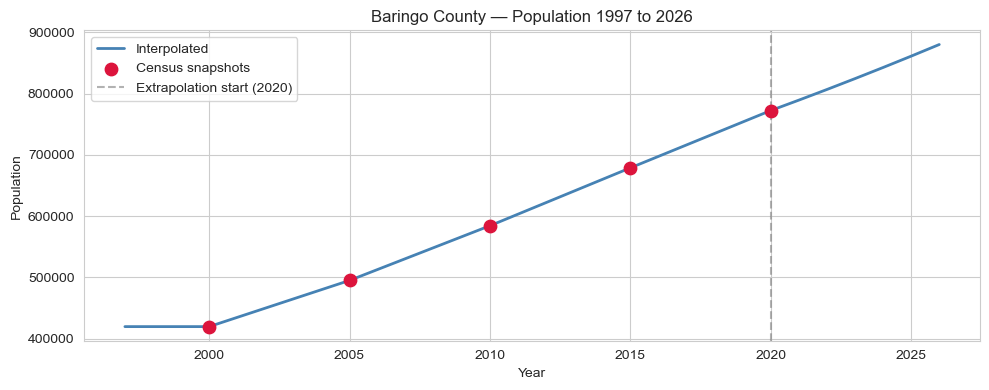

In [11]:
# Sanity check — plot Baringo population to confirm smooth interpolation
baringo = pwd_filled[pwd_filled['Adm_N'] == 'Baringo'].sort_values('year')
census_years = [2000, 2005, 2010, 2015, 2020]
baringo_census = baringo[baringo['year'].isin(census_years)]

plt.figure(figsize=(10, 4))
plt.plot(baringo['year'], baringo['Pop'], color='steelblue', linewidth=2, label='Interpolated')
plt.scatter(baringo_census['year'], baringo_census['Pop'],
            color='crimson', zorder=5, s=80, label='Census snapshots')
plt.axvline(2020, color='gray', linestyle='--', alpha=0.6, label='Extrapolation start (2020)')
plt.title('Baringo County — Population 1997 to 2026')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()


**Note:**  
Red dots = known census values. Blue line = interpolated/extrapolated smoothly between them. The dashed line marks where 2.2% annual extrapolation begins.


### 2.7 Merge Population Features onto ACLED

Attaching the 5 population features to each ACLED row using a **left merge** on county name and year.

A left merge because:
- Every ACLED row is kept, regardless of whether a matching population row exists
- Population values are attached where county + year matches
- Counties that had no conflict events in a given year simply do not appear in ACLED and do not need a row in the merged dataset


In [12]:
# Prepare the reference table for merging
pwd_merge = pwd_filled[['Adm_N', 'year'] + PWD_VALUE_COLS].copy()
pwd_merge = pwd_merge.rename(columns={'Adm_N': 'ADMIN1', 'year': 'YEAR'})

# Rename columns to make them clearly identifiable in the merged dataset
pwd_merge = pwd_merge.rename(columns={
    'Pop':     'PWD_POPULATION',
    'Density': 'PWD_DENSITY',
    'Area':    'PWD_AREA_KM2',
    'PWD_G':   'PWD_G',
    'PWD_D10': 'PWD_D10'
})

print('Population reference table ready for merge:')
print(f'  Shape: {pwd_merge.shape}')
print(f'  Columns: {pwd_merge.columns.tolist()}')


Population reference table ready for merge:
  Shape: (1410, 7)
  Columns: ['ADMIN1', 'YEAR', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']


In [13]:
# Perform the merge
rows_before = len(acled)
df = acled.merge(pwd_merge, on=['ADMIN1', 'YEAR'], how='left')
rows_after  = len(df)

print(f'Rows before merge: {rows_before:,}')
print(f'Rows after merge:  {rows_after:,}')
print(f'Row count preserved: {rows_before == rows_after}')
print()

# Check for any rows that did not get a population value
unmatched = df['PWD_POPULATION'].isna().sum()
print(f'Rows without population after merge: {unmatched}')


Rows before merge: 16,627
Rows after merge:  16,627
Row count preserved: True

Rows without population after merge: 0


### 2.8 Final Working Dataset Overview


In [14]:
# Final shape and column audit
print('=== FINAL MERGED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== FINAL MERGED DATASET ===
Shape: 16,627 rows x 19 columns

Columns:
  WEEK                           dtype=datetime64[ns] nulls=0 (0.0%)
  REGION                         dtype=object       nulls=0 (0.0%)
  COUNTRY                        dtype=object       nulls=0 (0.0%)
  ADMIN1                         dtype=object       nulls=0 (0.0%)
  EVENT_TYPE                     dtype=object       nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=object       nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=float64      nulls=4897 (29.5%)
  DISORDER_TYPE                  dtype=object       nulls=0 (0.0%)
  ID                             dtype=int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=int32        

In [15]:
# Preview
df.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [16]:
# Save the merged dataset
OUTPUT_FILE = 'kenya_conflict_merged.csv'
df.to_csv(OUTPUT_FILE, index=False)
print(f'Dataset saved to {OUTPUT_FILE}')
print(f'Shape: {df.shape}')


Dataset saved to kenya_conflict_merged.csv
Shape: (16627, 19)


### Summary of Dataset Creation Decisions

| Decision | Rationale |
|---|---|
| Pre-filtered ACLED to Kenya in Excel | File size only — no analytical impact |
| Selected 5 PWD columns from 25 available | Pop, Density, Area, PWD_G, PWD_D10 — theoretically motivated, non-redundant |
| Standardised 2 county names | Elgeyo-Marakwet and Murang'a spelling differences between sources |
| Linear interpolation between census years | Population grows continuously, not in 5-year steps |
| Backfill pre-2000 with 2000 value | No earlier data available; earliest known value is best available prior |
| 2.2% growth rate for post-2020 | KNBS 2019 Census inter-censal rate 2009–2019 (Figure 2.2) |
| Left merge on county + year | Preserves all ACLED rows; attaches population only where events exist |


---
## 3. Data Understanding
---


### 3.1 Dataset Preview
Taking a look at the now identified working dataset;

In [17]:
df.head()


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [18]:
# Shape
print(f'Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.')


Dataset contains 16,627 rows and 19 columns.


**Note:**  
The dataset contains 16,627 rows and columns spanning conflict event details, temporal markers, and population features derived from the WorldPop PWD merge above.


In [19]:
# Data types and null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   WEEK                 16627 non-null  datetime64[ns]
 1   REGION               16627 non-null  object        
 2   COUNTRY              16627 non-null  object        
 3   ADMIN1               16627 non-null  object        
 4   EVENT_TYPE           16627 non-null  object        
 5   SUB_EVENT_TYPE       16627 non-null  object        
 6   EVENTS               16627 non-null  int64         
 7   FATALITIES           16627 non-null  int64         
 8   POPULATION_EXPOSURE  11730 non-null  float64       
 9   DISORDER_TYPE        16627 non-null  object        
 10  ID                   16627 non-null  int64         
 11  CENTROID_LATITUDE    16627 non-null  float64       
 12  CENTROID_LONGITUDE   16627 non-null  float64       
 13  YEAR                 16627 non-

**Note:**  
`POPULATION_EXPOSURE` is the only column with missing values (~29.4%). All other columns are fully populated.
This confirms the dataset is structurally clean and ready for data preparation.


In [20]:
# Statistical summary
df.describe(include='all')


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
count,16627,16627,16627,16627,16627,16627,16627.000000,16627.000000,1.173000e+04,16627,16627.000000,16627.000000,16627.000000,16627.000000,1.662700e+04,16627.000000,16627.000000,16627.000000,1.662700e+04
unique,NaN,1,1,47,6,24,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Eastern Africa,Kenya,Nairobi,Protests,Peaceful protest,NaN,NaN,NaN,Political violence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16627,16627,1932,5474,4734,NaN,NaN,NaN,8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2019-10-10 23:34:06.286161152,NaN,NaN,NaN,NaN,NaN,1.294882,0.949600,3.774653e+04,NaN,1557.682444,-0.360952,36.905008,2019.288567,1.551337e+06,1130.021052,12907.134916,3512.448162,8.692382e+04
min,1997-01-11 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000e+00,NaN,1535.000000,-4.119800,34.205100,1997.000000,8.530900e+04,3.700000,260.900000,17.300000,1.665200e+03
25%,2017-01-14 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,5.358750e+03,NaN,1547.000000,-1.301900,35.306000,2017.000000,8.065620e+05,65.224438,2349.863681,244.480000,1.332418e+04
50%,2022-10-22 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.582100e+04,NaN,1559.000000,-0.467500,36.827000,2022.000000,1.241895e+06,274.260000,3589.100000,615.880000,2.252690e+04
75%,2024-10-12 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,3.932300e+04,NaN,1565.000000,0.497900,37.777500,2024.000000,1.820566e+06,653.831618,14110.443056,1058.977284,4.199972e+04
max,2026-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,21.000000,281.000000,1.475399e+06,NaN,1581.000000,3.220100,40.711200,2026.000000,5.349955e+06,7518.607822,81254.702191,28521.210865,1.743386e+06


**Note:**  
`FATALITIES` is dominated by zeros (median = 0, mean < 1) with a small number of extreme events pulling the max to 281 — a classic rare-event, long-tail problem.
Most modelling difficulty in this project will come from this distribution, not from messy data.
Categorically, the data skews toward non-lethal unrest: 'Protests' and 'Peaceful protest' are the most common event types.


### 3.2 Duplicate Check


In [21]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')


Number of duplicate rows: 0


**Note:**  
0 duplicate rows found. No action required.


### 3.3 Skewness of Key Numeric Columns


In [22]:
numeric_skew_cols = ['EVENTS', 'FATALITIES', 'PWD_POPULATION', 'PWD_DENSITY']
df[numeric_skew_cols].skew()


EVENTS             6.114555
FATALITIES        26.131026
PWD_POPULATION     1.699592
PWD_DENSITY        2.097458
dtype: float64

**Note:**
- `FATALITIES` (skew ~26) → extremely skewed. Almost all values are 0, with a few extreme outliers up to 281. Confirms the zero-inflation problem.
- `EVENTS` (skew ~6) → also right-skewed but less extreme. Most county-weeks have just 1 event.
- `PWD_POPULATION` and `PWD_DENSITY` → moderately skewed, driven by outlier counties like Nairobi. These will be log-transformed in data preparation.


### 3.4 Correlation Between Numeric Features


In [23]:
df.corr(numeric_only=True)


,EVENTS,FATALITIES,POPULATION_EXPOSURE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
EVENTS,1.000000,0.200076,0.422786,0.032327,-0.036531,-0.043209,0.027041,0.206028,0.195513,-0.063745,0.205163,0.046013
FATALITIES,0.200076,1.000000,0.123113,0.043812,0.098998,0.060109,-0.182143,-0.058070,-0.040378,0.127712,-0.030950,0.016928
POPULATION_EXPOSURE,0.422786,0.123113,1.000000,0.077284,-0.085880,0.113744,-0.051278,0.494683,0.499000,-0.063314,0.517064,0.117463
ID,0.032327,0.043812,0.077284,1.000000,0.137762,-0.057577,-0.085199,0.125868,0.177133,0.147358,0.183665,0.034276
CENTROID_LATITUDE,-0.036531,0.098998,-0.085880,0.137762,1.000000,-0.207489,-0.027197,-0.152940,-0.376241,0.497238,-0.308346,-0.277144
CENTROID_LONGITUDE,-0.043209,0.060109,0.113744,-0.057577,-0.207489,1.000000,-0.059174,-0.037488,0.028695,0.315190,0.031080,0.310992
YEAR,0.027041,-0.182143,-0.051278,-0.085199,-0.027197,-0.059174,1.000000,0.130207,-0.005700,-0.072034,-0.017829,0.027808
PWD_POPULATION,0.206028,-0.058070,0.494683,0.125868,-0.152940,-0.037488,0.130207,1.000000,0.819646,-0.258228,0.868458,0.150798
PWD_DENSITY,0.195513,-0.040378,0.499000,0.177133,-0.376241,0.028695,-0.005700,0.819646,1.000000,-0.341344,0.976598,0.286565
PWD_AREA_KM2,-0.063745,0.127712,-0.063314,0.147358,0.497238,0.315190,-0.072034,-0.258228,-0.341344,1.000000,-0.288755,-0.151885


**Note:**
Population, density, and most numeric features show only weak linear correlation with fatalities — the real predictive signal is likely non-linear and will need tree-based models to uncover.


### 3.5 Categorical vs Numerical Columns


In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', categorical_cols)
print('\nNumerical columns:', numerical_cols)
print(f'\nTotal categorical: {len(categorical_cols)}')
print(f'Total numerical: {len(numerical_cols)}')


Categorical columns: ['REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'DISORDER_TYPE']

Numerical columns: ['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']

Total categorical: 6
Total numerical: 11


---
## 4. Data Cleaning
---
To ensure the dataset is analytically sound before modelling, each column is examined individually — checking data types, redundancy, missing values, and distributions — to surface any inconsistencies that broader summary statistics might overlook.


### 4.1 Dropping Redundant Columns
Some columns present no meaning to us such as country, as they are already filtered to this specific use case.

In [25]:
# Check for constant (zero-variance) columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Constant columns:', constant_cols)


Constant columns: ['REGION', 'COUNTRY']


In [26]:
# Drop constant columns — they carry no information for modelling
df = df.drop(columns=['REGION', 'COUNTRY'])


In [27]:
# Drop ID and Column as it is not meaningful predictors
df = df.drop(columns=['ID'])
print(f'Shape after dropping constant columns: {df.shape}')

Shape after dropping constant columns: (16627, 16)


**Note:**  
`REGION` (constant: 'Eastern Africa') and `COUNTRY` (constant: 'Kenya') dropped. These columns carry zero variance and therefore zero predictive value.  
`ID` is also dropped as it offers no predictive information.


### 4.2 Investigating DISORDER_TYPE vs EVENT_TYPE Columns
Checking if each column offers different or meaningful information

In [28]:
# Check whether DISORDER_TYPE adds information beyond EVENT_TYPE
df.groupby('DISORDER_TYPE')['EVENT_TYPE'].unique()


DISORDER_TYPE
Demonstrations                                                        [Protests, Riots]
Political violence                    [Battles, Explosions/Remote violence, Riots, V...
Political violence; Demonstrations                                           [Protests]
Strategic developments                                         [Strategic developments]
Name: EVENT_TYPE, dtype: object

**Note:**  
`DISORDER_TYPE` is a higher-level grouping of `EVENT_TYPE` and does not add independent information.  
Notably, *Riots* appears under both *Demonstrations* and *Political violence* — meaning the grouping is not even a clean one-to-one mapping.  
`DISORDER_TYPE` is therefore both redundant and slightly inconsistent. We drop it and rely on the more granular `EVENT_TYPE` and `SUB_EVENT_TYPE`.


In [29]:
df = df.drop(columns=['DISORDER_TYPE'])
print(f'Shape after dropping DISORDER_TYPE: {df.shape}')


Shape after dropping DISORDER_TYPE: (16627, 15)


### 4.3 POPULATION_EXPOSURE Column Missing Value Treatment

`POPULATION_EXPOSURE` is ACLED's estimate of the number of people directly in the vicinity of a specific conflict event. It is an **event-level** figure, not a county-level one — it varies from event to event within the same county.

As this is fundamentally different from `PWD_POPULATION`, which is the total county population, imputing missing exposure values using county population would replace a fine-grained event-level figure with a county-wide total which would be conceptually wrong and likely to introduce noise rather than signal.

**Approach:**  Create a binary flag `HAS_EXPOSURE_ESTIMATE` (1 if present, 0 if missing) and leave the original column with NaN intact. XGBoost and Random Forest handle NaN natively. The flag column itself may carry signal — the *absence* of an exposure estimate is systematic by event type, not random.


In [30]:
# Check whether missingness is linked to specific event types
exposure_by_type = df.groupby('EVENT_TYPE')['POPULATION_EXPOSURE'].apply(
    lambda x: f"{x.notna().sum()} / {len(x)} ({x.notna().mean()*100:.0f}% present)"
)
print('POPULATION_EXPOSURE availability by event type:')
print(exposure_by_type.to_string())


POPULATION_EXPOSURE availability by event type:
EVENT_TYPE
Battles                       1029 / 1802 (57% present)
Explosions/Remote violence      222 / 358 (62% present)
Protests                      4669 / 5474 (85% present)
Riots                         4046 / 4764 (85% present)
Strategic developments            0 / 1411 (0% present)
Violence against civilians    1764 / 2818 (63% present)


**Note:**  
Missingness in POPULATION_EXPOSURE is not random — it is systematically associated with event type. This confirms that a binary flag column will carry real signal rather than just noise.


In [31]:
# Create the binary flag
df['HAS_EXPOSURE_ESTIMATE'] = df['POPULATION_EXPOSURE'].notna().astype('Int64')

print('HAS_EXPOSURE_ESTIMATE value counts:')
print(df['HAS_EXPOSURE_ESTIMATE'].value_counts())

# POPULATION_EXPOSURE NaN rows left intact for native handling by tree-based models.

HAS_EXPOSURE_ESTIMATE value counts:
HAS_EXPOSURE_ESTIMATE
1    11730
0     4897
Name: count, dtype: Int64


### 4.4 Column Standardization
Cleaning up and standardizing the column titles for ease of use.

In [32]:
# Standardising all column names: uppercase, underscores for spaces
df = df.rename(columns={
    'ADMIN1':               'COUNTY',
    'PWD_POPULATION':       'COUNTY_POPULATION',
    'PWD_DENSITY':          'COUNTY_RAW_DENSITY',
    'PWD_AREA_KM2':         'COUNTY_AREA_KM2',
    'PWD_G':                'COUNTY_WEIGHTED_DENSITY',
    'PWD_D10':              'COUNTY_URBAN_CORE_DENSITY',
})

print('Renamed columns:')
print(df.columns.tolist())

Renamed columns:
['WEEK', 'COUNTY', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'YEAR', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY', 'COUNTY_AREA_KM2', 'COUNTY_WEIGHTED_DENSITY', 'COUNTY_URBAN_CORE_DENSITY', 'HAS_EXPOSURE_ESTIMATE']


In [33]:
# Checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   WEEK                       16627 non-null  datetime64[ns]
 1   COUNTY                     16627 non-null  object        
 2   EVENT_TYPE                 16627 non-null  object        
 3   SUB_EVENT_TYPE             16627 non-null  object        
 4   EVENTS                     16627 non-null  int64         
 5   FATALITIES                 16627 non-null  int64         
 6   POPULATION_EXPOSURE        11730 non-null  float64       
 7   CENTROID_LATITUDE          16627 non-null  float64       
 8   CENTROID_LONGITUDE         16627 non-null  float64       
 9   YEAR                       16627 non-null  int32         
 10  COUNTY_POPULATION          16627 non-null  float64       
 11  COUNTY_RAW_DENSITY         16627 non-null  float64       
 12  COUN

In [34]:
# Fix data types
# POPULATION_EXPOSURE — event-level exposure count, must be whole people
# Use Int64 (nullable integer) rather than int64 to preserve NaN values
df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].astype('Int64')

# Converting Int32 to Int64
df['YEAR']    = df['YEAR'].astype('Int64')
df['HAS_EXPOSURE_ESTIMATE']  = df['HAS_EXPOSURE_ESTIMATE'].astype('Int64')
print('Datatype changed for YEAR, POPULATION_EXPOSURE and HAS_EXPOSURE_ESTIMATE Columns')

Datatype changed for YEAR, POPULATION_EXPOSURE and HAS_EXPOSURE_ESTIMATE Columns


### 4.5 Feature Engineering

Deriving additional features from existing columns to enrich the model's signal.  
Earlier noted that Population and Population Density are heavily skewed columns. Approach is to take the logarithm


In [35]:
# Election year flag — Kenya's general elections: 2002, 2007, 2013, 2017, 2022
election_years = [2002, 2007, 2013, 2017, 2022]
df['IS_ELECTION_YEAR'] = df['YEAR'].isin(election_years).astype('Int64')

# Log transforms for heavily skewed population columns
# Adding 1 before log to handle any zero values safely
df['LOG_COUNTY_POPULATION'] = np.log1p(df['COUNTY_POPULATION'])
df['LOG_COUNTY_RAW_DENSITY']    = np.log1p(df['COUNTY_RAW_DENSITY'])



For escalation signalling, Establish a four week rolling period leading up to the event occurence

In [36]:
# Sort first so the rolling window looks backward correctly
df = df.sort_values(['COUNTY', 'WEEK'])

# Rolling 4-week violent event count per county
df['EVENTS_ROLLING_4W'] = (
    df.groupby('COUNTY')['EVENTS']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum()).astype('Int64')
)


For events where four week prior data is unavailable, fill zero instead of null

In [37]:
df['EVENTS_ROLLING_4W'] = df['EVENTS_ROLLING_4W'].fillna(0)


**Note:**  
- IS_ELECTION_YEAR flags the 6 general election years in the dataset — a theoretically motivated signal given Kenya's electoral violence history.
- Log transforms on population and density reduce right-skew before modelling, particularly important for the Linear Regression baseline.  
- A rolling four week column for events has been added to allow escalation estimation


### 4.6 Final Dataset State


In [38]:
print('=== CLEANED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns and null counts:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== CLEANED DATASET ===
Shape: 16,627 rows x 20 columns

Columns and null counts:
  WEEK                           dtype=datetime64[ns] nulls=0 (0.0%)
  COUNTY                         dtype=object       nulls=0 (0.0%)
  EVENT_TYPE                     dtype=object       nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=object       nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=Int64        nulls=4897 (29.5%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=Int64        nulls=0 (0.0%)
  COUNTY_POPULATION              dtype=float64      nulls=0 (0.0%)
  COUNTY_RAW_DENSITY             dtype=float64      nulls=0 (0.0%)
  COUNTY_AREA_KM2                dtype=float64      nulls=0 (0.0%)
  COUNTY_WEIGHTED_DENSITY        dtype=fl

In [39]:
# Final preview
df.head()


,WEEK,COUNTY,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,COUNTY_POPULATION,COUNTY_RAW_DENSITY,COUNTY_AREA_KM2,COUNTY_WEIGHTED_DENSITY,COUNTY_URBAN_CORE_DENSITY,HAS_EXPOSURE_ESTIMATE,IS_ELECTION_YEAR,LOG_COUNTY_POPULATION,LOG_COUNTY_RAW_DENSITY,EVENTS_ROLLING_4W
0,1998-01-24,Baringo,Battles,Armed clash,1,0,<NA>,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,0,0,12.947257,3.693867,0
89,1998-06-27,Baringo,Protests,Peaceful protest,1,0,<NA>,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,0,0,12.947257,3.693867,1
1,1999-01-16,Baringo,Battles,Armed clash,1,0,<NA>,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,0,12.947257,3.693867,2
2,1999-09-25,Baringo,Battles,Armed clash,1,0,<NA>,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,0,12.947257,3.693867,3
295,1999-09-25,Baringo,Violence against civilians,Attack,1,0,<NA>,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,0,0,12.947257,3.693867,4


In [40]:
# Save cleaned dataset
df.to_csv('kenya_conflict_clean.csv', index=False)
print('Cleaned dataset saved to kenya_conflict_clean.csv')
print(f'Shape: {df.shape}')


Cleaned dataset saved to kenya_conflict_clean.csv
Shape: (16627, 20)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16627 entries, 0 to 16499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   WEEK                       16627 non-null  datetime64[ns]
 1   COUNTY                     16627 non-null  object        
 2   EVENT_TYPE                 16627 non-null  object        
 3   SUB_EVENT_TYPE             16627 non-null  object        
 4   EVENTS                     16627 non-null  int64         
 5   FATALITIES                 16627 non-null  int64         
 6   POPULATION_EXPOSURE        11730 non-null  Int64         
 7   CENTROID_LATITUDE          16627 non-null  float64       
 8   CENTROID_LONGITUDE         16627 non-null  float64       
 9   YEAR                       16627 non-null  Int64         
 10  COUNTY_POPULATION          16627 non-null  float64       
 11  COUNTY_RAW_DENSITY         16627 non-null  float64       
 12  COUNTY_AR

---
### Summary of Data Preparation Decisions

| Decision | Rationale |
|---|---|
| Dropped REGION, COUNTRY | Constant columns — zero variance, zero predictive value |
| Dropped ID | Information contained does not contribute to modelling predictability |
| Dropped DISORDER_TYPE | Redundant with EVENT_TYPE and inconsistently mapped |
| Left POPULATION_EXPOSURE NaN intact | Created HAS_EXPOSURE_ESTIMATE flag as Missingness is systematic by event type, may carry predictive signal |
| Added EVENTS_ROLLING_4W | To factor in conflict escalation patterns |
| Added IS_ELECTION_YEAR | Electoral cycles are theoretically the key driver of violence spikes |
| Log-transformed population and density | Reduces right-skew; important for Linear Regression baseline |

---

# 5. Exploratory Data Analysis

 This section explores the cleaned dataset through outlier detection, univariate analysis of individual distributions, and bivariate analysis of feature–target relationships — surfacing the patterns that will inform modelling decisions.

## 5.1 Outlier Detection

## Outliers in key numeric columns

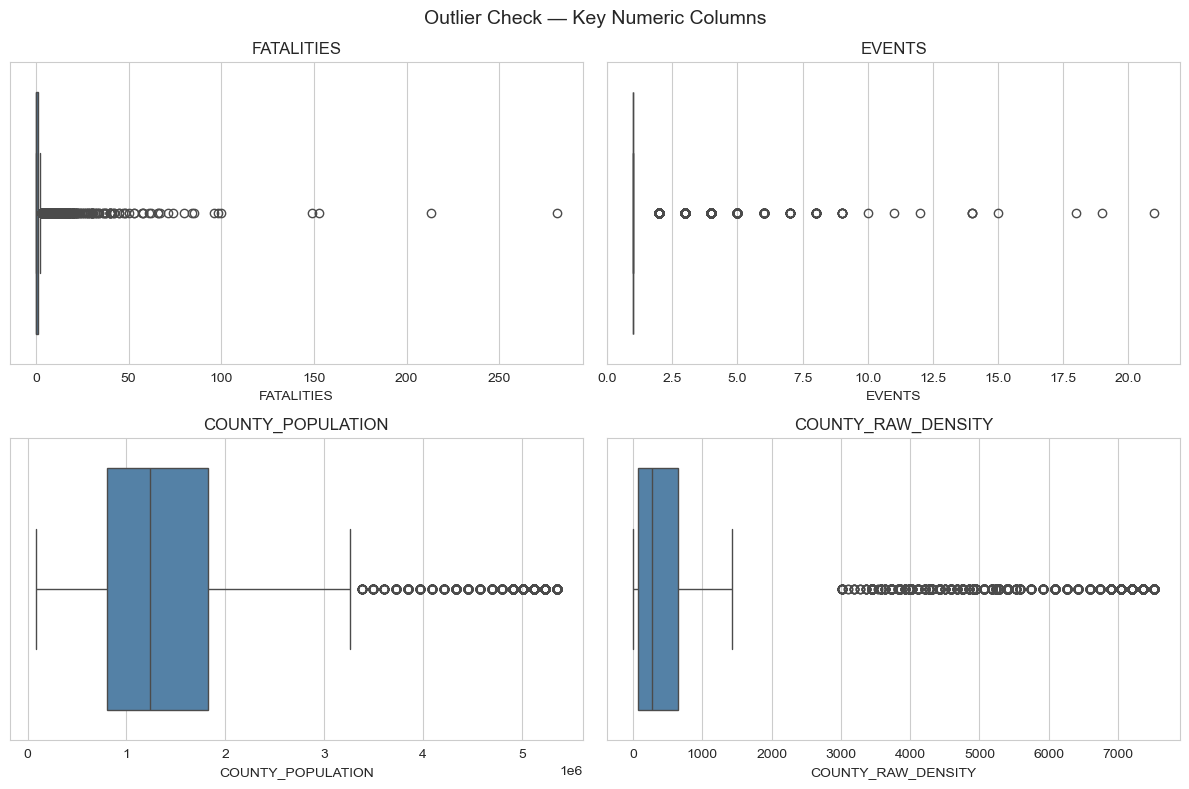

In [42]:
# Boxplots to visualise outliers in key numeric columns
outlier_cols = ['FATALITIES', 'EVENTS', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=12)
plt.suptitle('Outlier Check — Key Numeric Columns', fontsize=14)
plt.tight_layout()
plt.show()

**Note:**  
- All outliers are retained — in this problem they are the phenomenon of interest, not noise to be cleaned.
- FATALITIES extremes (max 281) correspond to genuine mass-violence events — the exact outcomes this project must predict; their influence is managed through robust evaluation (MAE alongside RMSE) and tree-based models.
- EVENTS outliers (15–21 events per week) represent real escalation periods — the signal captured by EVENTS_ROLLING_4W.
- COUNTY_POPULATION and COUNTY_RAW_DENSITY outliers are structurally dense urban counties (Nairobi, Mombasa) appearing repeatedly across weeks — already addressed via the log transforms in Section 4.5.

## outliers per column using the IQR rule

In [43]:
# Count outliers per column using the IQR rule (1.5 x IQR beyond Q1/Q3)
outlier_summary = []
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Column': col,
        'Q1': q1, 'Q3': q3,
        'Upper Bound': upper,
        'Max Value': df[col].max(),
        'Outliers': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 1)
    })

pd.DataFrame(outlier_summary)

,Column,Q1,Q3,Upper Bound,Max Value,Outliers,Outlier %
0,FATALITIES,0.000000,1.000000e+00,2.500000e+00,2.810000e+02,1429,8.6
1,EVENTS,1.000000,1.000000e+00,1.000000e+00,2.100000e+01,3050,18.3
2,COUNTY_POPULATION,806562.034124,1.820566e+06,3.341571e+06,5.349955e+06,1550,9.3
3,COUNTY_RAW_DENSITY,65.224438,6.538316e+02,1.536742e+03,7.518608e+03,2546,15.3


**Note:**  
- FATALITIES: 1,429 rows (8.6%) are flagged because most weeks have 0 or 1 fatalities, so anything above 2.5 counts as an outlier — these are real violent events, not errors.
- EVENTS: most weeks have exactly 1 event, so the rule flags every week with 2 or more (18.3%) — far too many to truly be outliers, showing the IQR rule struggles with count data like this.
- COUNTY_POPULATION and COUNTY_RAW_DENSITY: the flagged rows are just the big urban counties (like Nairobi) appearing week after week — real places, not bad data.
- Overall, the high percentages simply confirm the data is heavily skewed — the treatment decision is to keep them all

 ## The non-zero fatality tail

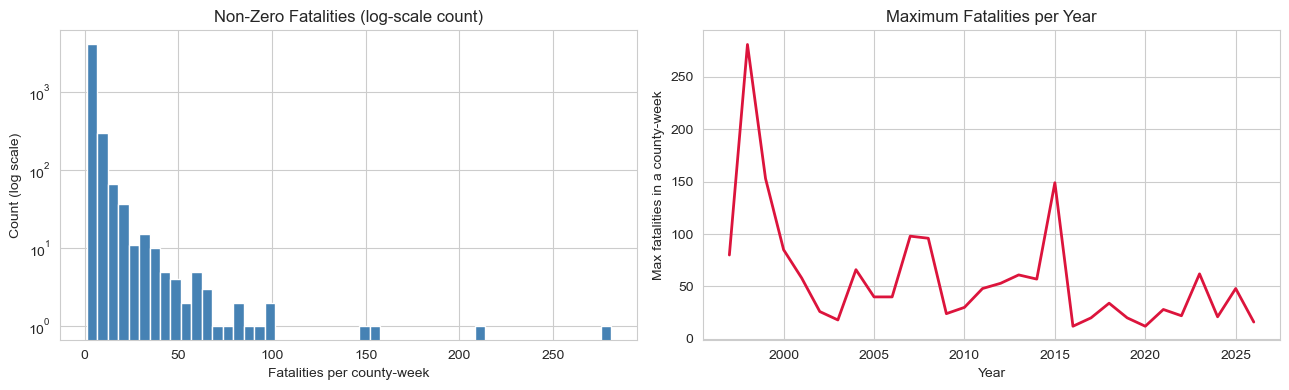

In [44]:
# Distribution of the non-zero fatality tail
nonzero = df[df['FATALITIES'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nonzero['FATALITIES'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Non-Zero Fatalities (log-scale count)')
axes[0].set_xlabel('Fatalities per county-week')
axes[0].set_ylabel('Count (log scale)')

nonzero.groupby(nonzero['WEEK'].dt.year)['FATALITIES'].max().plot(
    ax=axes[1], color='crimson', linewidth=2)
axes[1].set_title('Maximum Fatalities per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Max fatalities in a county-week')

plt.tight_layout()
plt.show()

**Note:**  
- Even among non-zero weeks, most have fewer than 10 fatalities — the counts drop off sharply, with only a handful of extreme weeks above 100.
- The yearly maximums line up with known events in Kenya's history: the largest spike (281) occurs in 1998 during the post-1997-election ethnic clashes, the 2007/08 post-election crisis is clearly visible, and the ~150 spike in 2015 matches the Garissa University attack.
- This confirms the extreme values are genuine historical events, not data errors.

**Outlier Treatment Decision:**  
- All outliers are kept — no removal, no capping.
- The extreme fatality weeks are exactly what this model exists to predict; deleting them would remove the very signal we want to learn.
- Their influence is managed instead by using MAE (a metric not distorted by extremes) alongside RMSE, and by tree-based models, which handle extreme values much better than linear regression.

## 5.2 Univariate Analysis

Examining the distribution of individual variables — the target, key categorical columns, and temporal patterns.

## Target variable distribution:

In [45]:
# Zero vs non-zero split — explicit ordering to avoid label mix-ups
zero_count    = (df['FATALITIES'] == 0).sum()
nonzero_count = (df['FATALITIES'] > 0).sum()

axes[0].bar(['Zero', 'Non-zero'], [zero_count, nonzero_count], color=['#1f4e79', '#6baed6'])
axes[0].set_title('FATALITIES — Zero vs Non-Zero Weeks')
axes[0].set_ylabel('Count')
for i, v in enumerate([zero_count, nonzero_count]):
    axes[0].text(i, v, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', va='bottom')

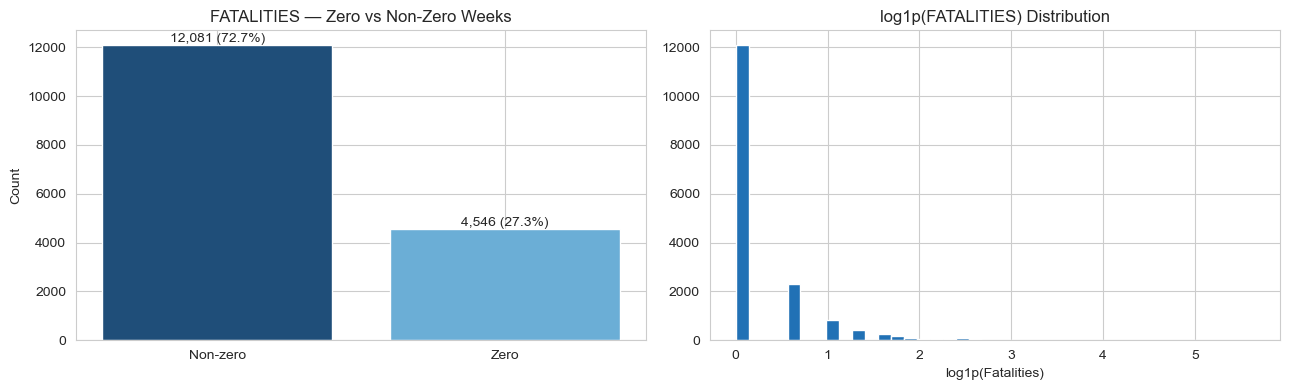

In [46]:
# Distribution of the target: FATALITIES
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Zero vs non-zero split
zero_split = (df['FATALITIES'] == 0).value_counts()
axes[0].bar(['Non-zero', 'Zero'], zero_split.values, color=['#1f4e79', '#6baed6'])
axes[0].set_title('FATALITIES — Zero vs Non-Zero Weeks')
axes[0].set_ylabel('Count')
for i, v in enumerate(zero_split.values):
    axes[0].text(i, v, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', va='bottom')

# Log-transformed distribution
axes[1].hist(np.log1p(df['FATALITIES']), bins=40, color='#2171b5', edgecolor='white')
axes[1].set_title('log1p(FATALITIES) Distribution')
axes[1].set_xlabel('log1p(Fatalities)')

plt.tight_layout()
plt.show()

,severity_band,rows,row_share
0,0 none,12081,0.726589
1,1 low (1-2),3117,0.187466
2,2 moderate (3-10),1191,0.071630
3,3 severe (11+),238,0.014314


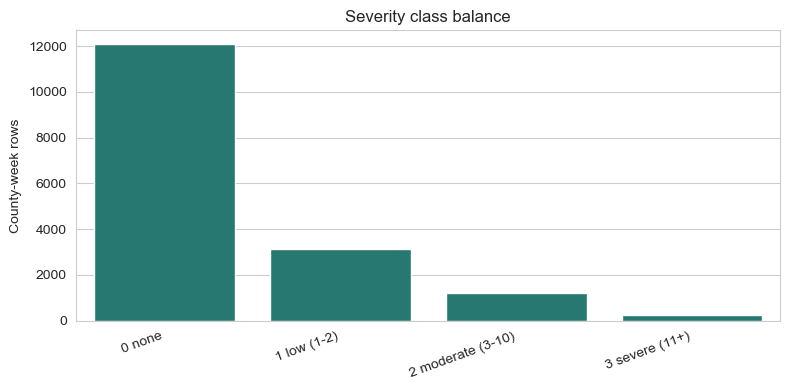

In [55]:

# Create an interpretable severity class for EDA and later classification-style diagnostics.
def severity_band(x):
    if x == 0:
        return "0 none"
    if x <= 2:
        return "1 low (1-2)"
    if x <= 10:
        return "2 moderate (3-10)"
    return "3 severe (11+)"

df["SEVERITY_BAND"] = df["FATALITIES"].apply(severity_band)
severity_table = (
    df["SEVERITY_BAND"]
    .value_counts()
    .rename_axis("severity_band")
    .reset_index(name="rows")
)
severity_table["row_share"] = severity_table["rows"] / len(df)
display(severity_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=severity_table, x="severity_band", y="rows", color="#19857b")
plt.title("Severity class balance")
plt.xlabel("")
plt.ylabel("County-week rows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Note:**  
- 72.7% of county-weeks (12,081) record zero fatalities, while only 27.3% (4,546) involve at least one death — confirming this is a rare-event prediction problem.
- Even after log transformation, the distribution remains dominated by the zero spike with a rapidly thinning tail — the skew comes from zero-inflation itself, which no transformation can remove.
- This shapes the modelling strategy: the models must learn both *when* violence turns deadly and *how* deadly it becomes.

## Event type Frequency

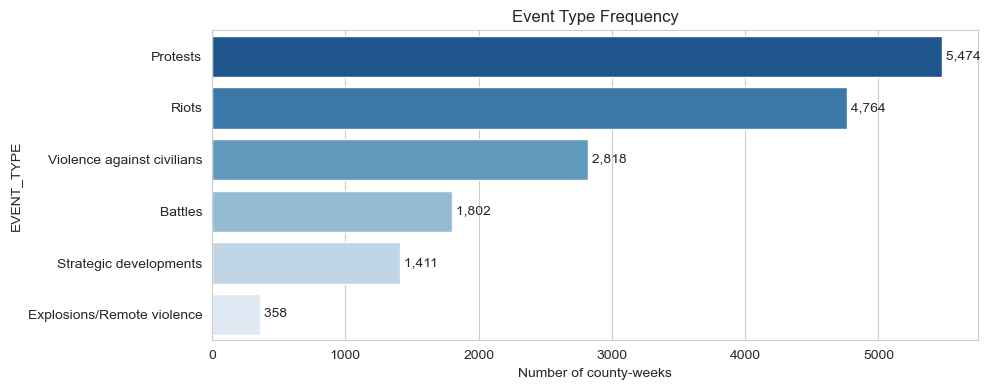

In [47]:
# Frequency of each event type
plt.figure(figsize=(10, 4))
event_counts = df['EVENT_TYPE'].value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index, palette='Blues_r')
plt.title('Event Type Frequency')
plt.xlabel('Number of county-weeks')
for i, v in enumerate(event_counts.values):
    plt.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

**Note:**  
- Protests (5,474) and Riots (4,764) dominate, together making up over 60% of all county-weeks — most conflict activity in Kenya is unrest, not warfare.
- Violence against civilians (2,818) and Battles (1,802) are less frequent but are the categories most likely to drive fatalities — a relationship to be confirmed in the bivariate analysis.
- Explosions/Remote violence is rare (358) but potentially high-severity per event.
- This imbalance suggests EVENT_TYPE will be a strong predictor: the *type* of event likely matters more for fatality severity than the raw *number* of events.

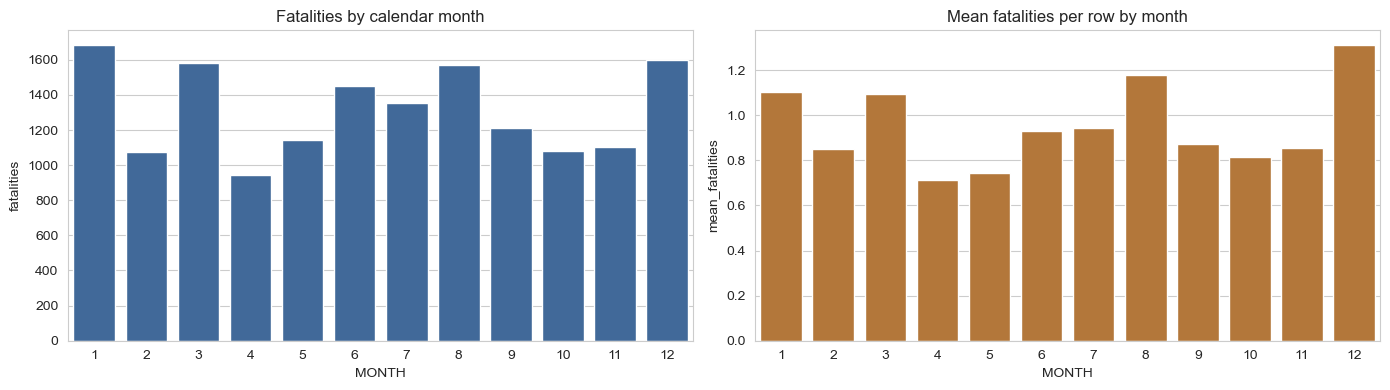

In [56]:
# Monthly seasonality: useful for early-warning calendars and feature engineering.
df["MONTH"] = df["WEEK"].dt.month
monthly = (
    df.groupby("MONTH")
    .agg(rows=("MONTH", "size"), fatalities=("FATALITIES", "sum"), mean_fatalities=("FATALITIES", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=monthly, x="MONTH", y="fatalities", ax=axes[0], color="#3268a8")
axes[0].set_title("Fatalities by calendar month")
sns.barplot(data=monthly, x="MONTH", y="mean_fatalities", ax=axes[1], color="#c77726")
axes[1].set_title("Mean fatalities per row by month")
plt.tight_layout()
plt.show()

,rows,events,fatalities,mean_fatalities,median_fatalities,fatal_row_share,severe_row_share
EVENT_TYPE,,,,,,,
Violence against civilians,2818,3459,6248,2.217175,1.0,0.583038,0.033357
Battles,1802,2302,5393,2.992786,1.0,0.622642,0.059378
Riots,4764,6461,2901,0.608942,0.0,0.320319,0.003568
Explosions/Remote violence,358,395,1112,3.106145,1.0,0.533520,0.050279
Protests,5474,7350,87,0.015893,0.0,0.009499,0.000183
Strategic developments,1411,1563,48,0.034018,0.0,0.008505,0.000709


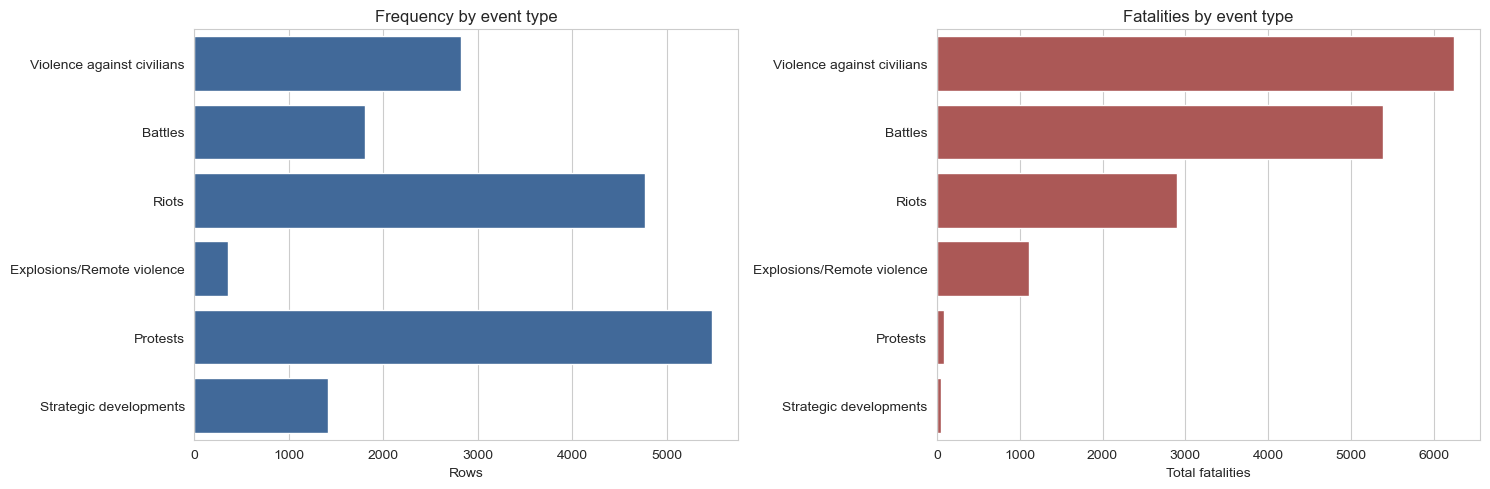

In [58]:
# Event-Type Severity

#This is one of the most important business-facing views. Not all disorder is equal: protests dominate row counts, but battles, remote violence, and violence against civilians drive fatalities.


event_type_summary = (
    df.groupby("EVENT_TYPE")
    .agg(
        rows=("EVENT_TYPE", "size"),
        events=("EVENTS", "sum"),
        fatalities=("FATALITIES", "sum"),
        mean_fatalities=("FATALITIES", "mean"),
        median_fatalities=("FATALITIES", "median"),
        fatal_row_share=("FATALITIES", lambda s: (s > 0).mean()),
        severe_row_share=("FATALITIES", lambda s: (s > 10).mean()),
    )
    .sort_values("fatalities", ascending=False)
)
display(event_type_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=event_type_summary.reset_index(), y="EVENT_TYPE", x="rows", ax=axes[0], color="#3268a8")
axes[0].set_title("Frequency by event type")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("")

sns.barplot(data=event_type_summary.reset_index(), y="EVENT_TYPE", x="fatalities", ax=axes[1], color="#b94a48")
axes[1].set_title("Fatalities by event type")
axes[1].set_xlabel("Total fatalities")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## counties by total events and total fatalities

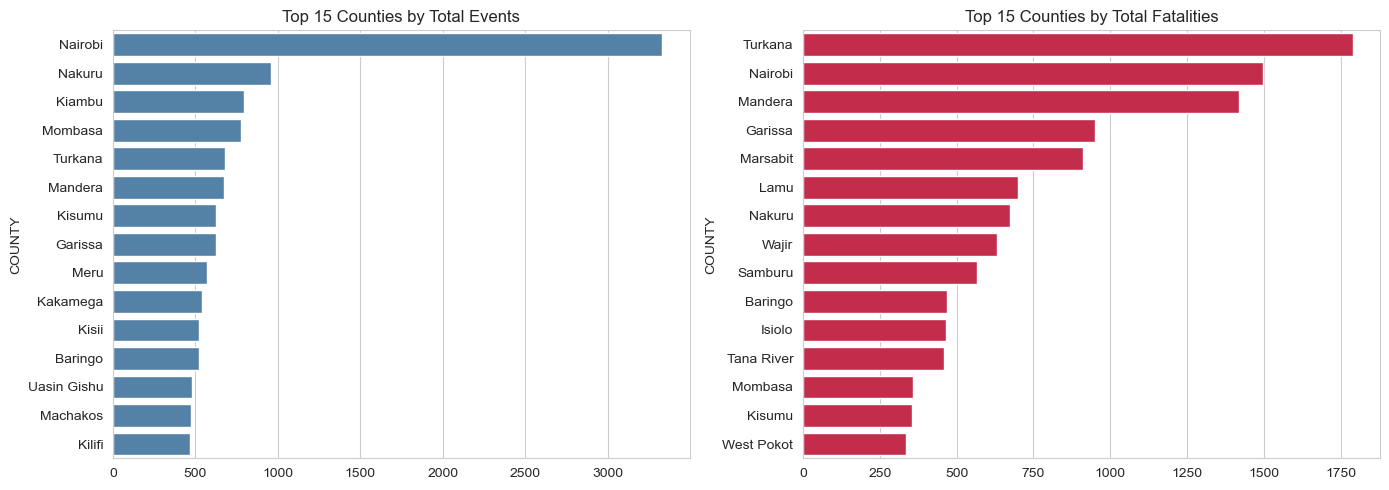

In [48]:
# Top 15 counties by total events and total fatalities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_events = df.groupby('COUNTY')['EVENTS'].sum().nlargest(15)
sns.barplot(x=top_events.values, y=top_events.index, color='steelblue', ax=axes[0])
axes[0].set_title('Top 15 Counties by Total Events')

top_fatal = df.groupby('COUNTY')['FATALITIES'].sum().nlargest(15)
sns.barplot(x=top_fatal.values, y=top_fatal.index, color='crimson', ax=axes[1])
axes[1].set_title('Top 15 Counties by Total Fatalities')

plt.tight_layout()
plt.show()

**Note:**  
- The two rankings tell different stories: Nairobi leads by far in total *events* (over 3,300 — nearly 3.5× second-place Nakuru), but Turkana leads in total *fatalities*.
- The fatality list is dominated by northern and pastoral counties — Turkana, Mandera, Garissa, Marsabit, Wajir, Samburu — where conflict is less frequent but far deadlier (cattle raids, cross-border attacks, inter-communal violence).
- Nairobi's high event count reflects its role as the centre of protests and riots, which are frequent but mostly non-lethal.
- This directly confirms the earlier point: event *frequency* and fatality *severity* are driven by different dynamics — supporting event type and county as key predictors, and aligning with the known hotspots (Turkana, Nairobi, Mandera, Garissa) named in the success criteria.

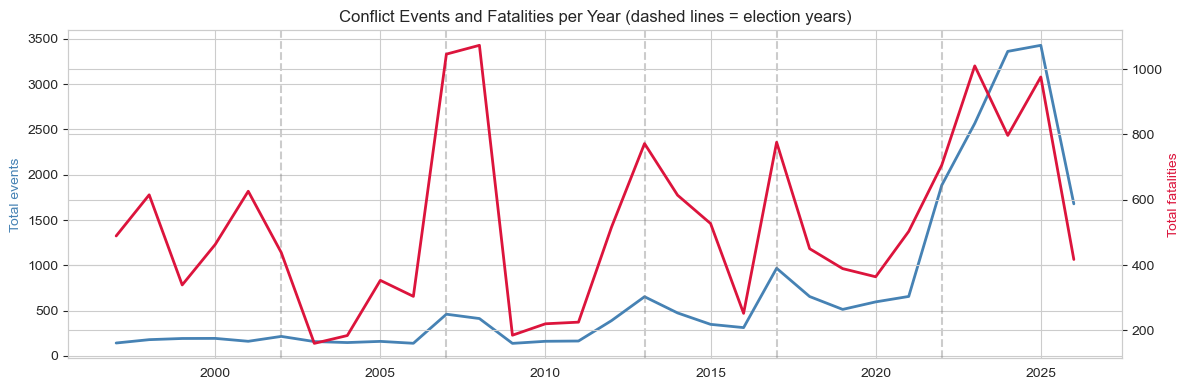

In [49]:
# Yearly totals: events and fatalities over time
yearly = df.groupby('YEAR')[['EVENTS', 'FATALITIES']].sum()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(yearly.index, yearly['EVENTS'], color='steelblue', linewidth=2, label='Events')
ax1.set_ylabel('Total events', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['FATALITIES'], color='crimson', linewidth=2, label='Fatalities')
ax2.set_ylabel('Total fatalities', color='crimson')

# Mark election years
for yr in [2002, 2007, 2013, 2017, 2022]:
    ax1.axvline(yr, color='gray', linestyle='--', alpha=0.4)

ax1.set_title('Conflict Events and Fatalities per Year (dashed lines = election years)')
plt.tight_layout()
plt.show()

**Note:**  
- Fatalities spike sharply around election years — 2007/08 shows the largest peak (the post-election crisis), with clear surges around 2013, 2017, and 2022/23 — strong visual evidence for the IS_ELECTION_YEAR feature.
- Events and fatalities move differently: events stayed relatively flat for two decades, then surged dramatically from 2021 onwards, peaking above 3,400 in 2024/25 — reflecting the recent wave of protests (e.g. the 2024 Finance Bill demonstrations).
- The recent period is high-events but comparatively lower fatalities per event — consistent with protest-driven unrest rather than mass-casualty violence.
- The apparent drop in 2026 is an artefact: the data only runs to June 2026, so it is a partial year, not a genuine decline.

### 5.3 Bivariate Analysis

Examining how key features relate to the target (FATALITIES) — event type, election cycles, population features, and the escalation signal.

## Fatalities per county-week by event type

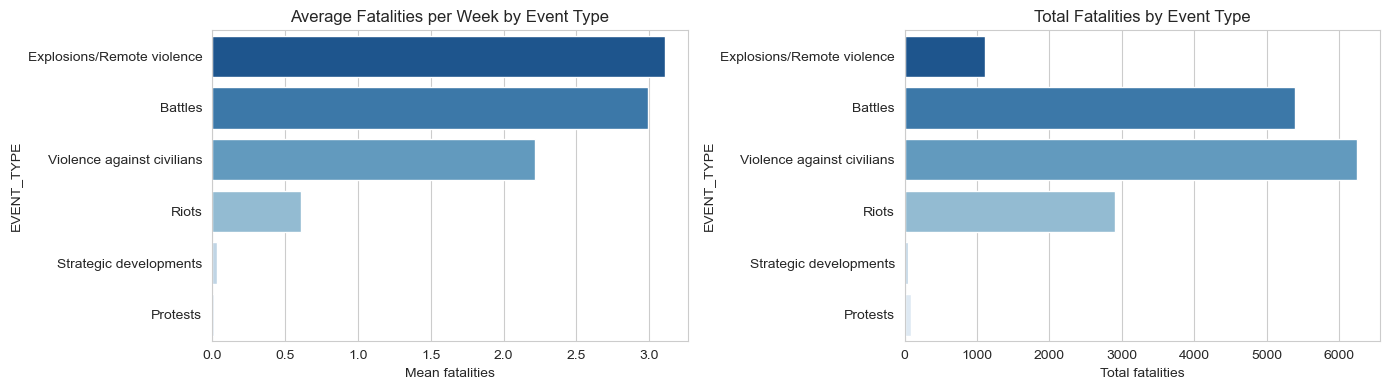

In [50]:
# Average fatalities per county-week by event type
fatal_by_type = df.groupby('EVENT_TYPE')['FATALITIES'].agg(['mean', 'sum']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x=fatal_by_type['mean'].values, y=fatal_by_type.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Average Fatalities per Week by Event Type')
axes[0].set_xlabel('Mean fatalities')

sns.barplot(x=fatal_by_type['sum'].values, y=fatal_by_type.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Fatalities by Event Type')
axes[1].set_xlabel('Total fatalities')

plt.tight_layout()
plt.show()

**Note:**  
- The deadliest events per week are Explosions/Remote violence and Battles (about 3 deaths each), while Protests — the most common event — cause almost no deaths.
- Violence against civilians has the highest total deaths overall (~6,200) because it is both fairly deadly and happens often. Explosions are the deadliest per event but rare, so their total stays low (~1,100).
- This flips the frequency chart from 5.2 upside down: the most common events are the least deadly, and the rarest ones are the most deadly.
- This confirms EVENT_TYPE should be one of the strongest predictors of fatalities.

## Election Cycles vs Violence Severity

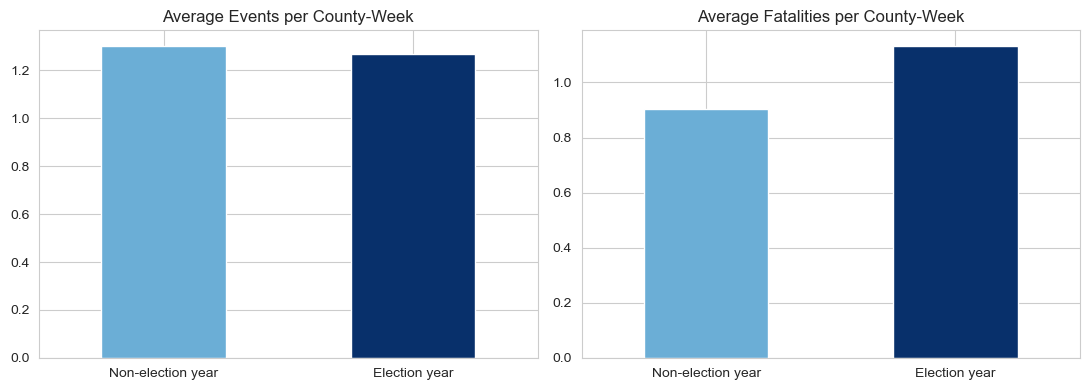

                   EVENTS  FATALITIES
Non-election year   1.302       0.904
Election year       1.267       1.132


In [51]:
# Do election years carry more violence?
election_compare = df.groupby('IS_ELECTION_YEAR')[['EVENTS', 'FATALITIES']].mean()
election_compare.index = ['Non-election year', 'Election year']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

election_compare['EVENTS'].plot(kind='bar', color=['#6baed6', '#08306b'], ax=axes[0], rot=0)
axes[0].set_title('Average Events per County-Week')

election_compare['FATALITIES'].plot(kind='bar', color=['#6baed6', '#08306b'], ax=axes[1], rot=0)
axes[1].set_title('Average Fatalities per County-Week')

plt.tight_layout()
plt.show()

print(election_compare.round(3))

**Note:**  
- Election years do not bring *more* events — the average number of events per week is almost the same (slightly lower, in fact).
- But election years do bring *deadlier* weeks: average fatalities rise from about 0.90 to about 1.13 — roughly 25% higher.
- In simple terms: elections don't cause more unrest overall, but the unrest that happens is more likely to turn deadly.
- This supports keeping IS_ELECTION_YEAR as a feature — it carries signal about severity, which is exactly what we're predicting.

## county population/density vs fatalities

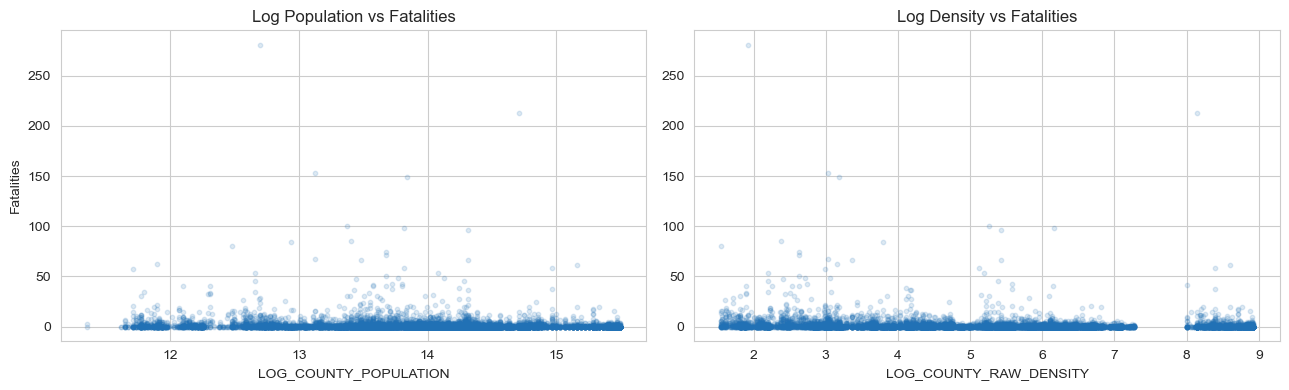

In [52]:
# Relationship between county population/density and fatalities
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['LOG_COUNTY_POPULATION'], df['FATALITIES'], alpha=0.15, color='#2171b5', s=10)
axes[0].set_title('Log Population vs Fatalities')
axes[0].set_xlabel('LOG_COUNTY_POPULATION')
axes[0].set_ylabel('Fatalities')

axes[1].scatter(df['LOG_COUNTY_RAW_DENSITY'], df['FATALITIES'], alpha=0.15, color='#2171b5', s=10)
axes[1].set_title('Log Density vs Fatalities')
axes[1].set_xlabel('LOG_COUNTY_RAW_DENSITY')

plt.tight_layout()
plt.show()

**Note:**  
- There is no clear pattern here — counties with more people or higher density are not automatically deadlier.
- In fact, the deadliest weeks (including the 281-death week) happened in *low*-density counties like Turkana and Mandera.
- The separate cluster on the far right of the density plot is Nairobi — lots of events, but mostly few deaths.
- So population and density alone can't predict deaths in a simple straight-line way — tree-based models will be needed to pick up the more complex patterns.

## Escalation Signal — Does Recent Activity Predict Deadly Weeks?

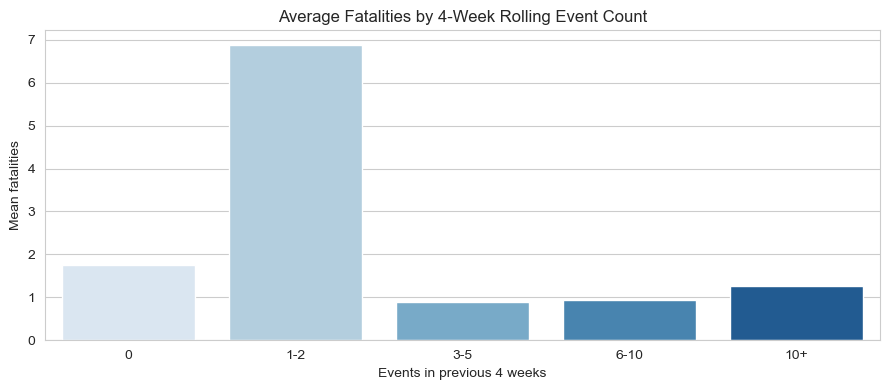

In [53]:
# Does recent activity predict deadly weeks?
df['ROLLING_BAND'] = pd.cut(df['EVENTS_ROLLING_4W'].astype(float),
                            bins=[-1, 0, 2, 5, 10, np.inf],
                            labels=['0', '1-2', '3-5', '6-10', '10+'])

band_stats = df.groupby('ROLLING_BAND')['FATALITIES'].mean()

plt.figure(figsize=(9, 4))
sns.barplot(x=band_stats.index, y=band_stats.values, palette='Blues')
plt.title('Average Fatalities by 4-Week Rolling Event Count')
plt.xlabel('Events in previous 4 weeks')
plt.ylabel('Mean fatalities')
plt.tight_layout()
plt.show()


**Note:**  
- Surprising result: the deadliest weeks come after *quiet* periods (only 1–2 events in the past month, ~7 deaths on average) — not after busy ones.
- Weeks with lots of recent activity (10+ events) average only about 1 death — busy periods are mostly protests, which are rarely deadly.
- The deadliest violence (raids and attacks in places like Turkana and Mandera) strikes with little warning.
- Simple takeaway: more activity does not mean more deaths — so the model needs to learn this twist, which tree-based models handle well.
```

## Correlation heatmap of numerical features vs Target Column

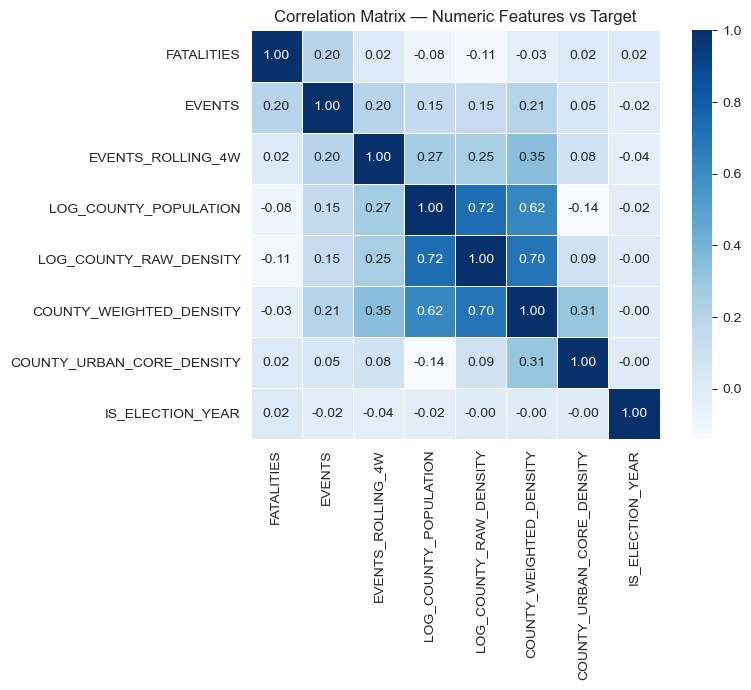

In [54]:
# Correlation heatmap of numeric features with the target
corr_cols = ['FATALITIES', 'EVENTS', 'EVENTS_ROLLING_4W', 'LOG_COUNTY_POPULATION',
             'LOG_COUNTY_RAW_DENSITY', 'COUNTY_WEIGHTED_DENSITY',
             'COUNTY_URBAN_CORE_DENSITY', 'IS_ELECTION_YEAR']

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].astype(float).corr(), annot=True, fmt='.2f',
            cmap='Blues', square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features vs Target')
plt.tight_layout()
plt.show()

**Note:**  
- No feature has a strong straight-line link with FATALITIES — the highest is EVENTS at just 0.20. This confirms the patterns are non-linear, so Linear Regression will struggle while tree-based models should do better.
- The population and density features are strongly linked to *each other* (0.62–0.72) — expected, since they all describe the same counties. Tree-based models handle this fine, but it will make Linear Regression's coefficients unreliable.
- IS_ELECTION_YEAR shows almost zero correlation (0.02) here, yet the bar chart showed election years are ~25% deadlier — a good reminder that low correlation doesn't mean a feature is useless; its effect is real but too subtle for a simple correlation to capture.
- Overall: weak linear signals everywhere support the choice of Random Forest, XGBoost, and Gradient Boosting as the main models.